# Winner-Takes-All (WTA) Competitive Learning Network

In a Winner-Takes-All network, neurons compete for the right to respond
to an input pattern. Only the single neuron whose weight vector is most
similar to the input (the "winner") gets its weights updated — all other
neurons remain unchanged.

**Update rule (for the winner only):**

$$\Delta w_{\text{winner}} = \eta \cdot (x - w_{\text{winner}})$$

This causes the winner's weight vector to move toward the input, and
over many iterations each neuron becomes the prototype for a cluster of
similar inputs — effectively performing unsupervised vector quantisation.

**Example:** We generate 2-D data from four Gaussian clusters and train a WTA
network with 4 neurons to discover the cluster centres.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

## 1. Generate Synthetic 2-D Clustered Data

In [2]:
rng = np.random.default_rng(42)

cluster_centres = np.array([
    [2.0,  2.0],
    [2.0, -2.0],
    [-2.0, 2.0],
    [-2.0, -2.0],
])

n_per_cluster = 100
std_dev = 0.5

data = np.vstack([
    rng.normal(loc=c, scale=std_dev, size=(n_per_cluster, 2))
    for c in cluster_centres
])
true_labels = np.repeat(np.arange(len(cluster_centres)), n_per_cluster)

# Shuffle
shuffle_idx = rng.permutation(len(data))
data = data[shuffle_idx]
true_labels = true_labels[shuffle_idx]

N_SAMPLES, INPUT_DIM = data.shape
print(f"Dataset: {N_SAMPLES} samples, {INPUT_DIM} dimensions, "
      f"{len(cluster_centres)} true clusters")

Dataset: 400 samples, 2 dimensions, 4 true clusters


## 2. WTA Network Parameters

In [3]:
N_NEURONS  = 4       # one per expected cluster
N_EPOCHS   = 50
INIT_LR    = 0.5
FINAL_LR   = 0.01

# Initialise neuron weights randomly from the data range
w_min, w_max = data.min(axis=0), data.max(axis=0)
weights = rng.uniform(w_min, w_max, size=(N_NEURONS, INPUT_DIM))

# Record weight trajectories for visualisation
weight_history = [weights.copy()]

## 3. Training Loop

In [4]:
def find_winner(x: np.ndarray, weights: np.ndarray) -> int:
    """Return index of the neuron closest to input x."""
    distances = np.linalg.norm(weights - x, axis=1)
    return np.argmin(distances)


print("Training WTA network ...")

for epoch in range(N_EPOCHS):
    # Linear learning-rate decay
    lr = INIT_LR - (INIT_LR - FINAL_LR) * (epoch / N_EPOCHS)

    order = rng.permutation(N_SAMPLES)
    for idx in order:
        x = data[idx]

        # Competition — find the winning neuron
        winner = find_winner(x, weights)

        # Cooperation / Adaptation — only the winner updates
        weights[winner] += lr * (x - weights[winner])

    weight_history.append(weights.copy())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        # Compute quantisation error (mean distance to nearest neuron)
        errors = [np.linalg.norm(data[i] - weights[find_winner(data[i], weights)])
                  for i in range(N_SAMPLES)]
        qe = np.mean(errors)
        print(f"  Epoch {epoch + 1:>3}/{N_EPOCHS}  |  lr={lr:.4f}  |  "
              f"quantisation error={qe:.4f}")

print("Training complete!")

Training WTA network ...
  Epoch   1/50  |  lr=0.5000  |  quantisation error=0.7022
  Epoch  10/50  |  lr=0.4118  |  quantisation error=0.6742
  Epoch  20/50  |  lr=0.3138  |  quantisation error=0.6429
  Epoch  30/50  |  lr=0.2158  |  quantisation error=0.6541
  Epoch  40/50  |  lr=0.1178  |  quantisation error=0.6316
  Epoch  50/50  |  lr=0.0198  |  quantisation error=0.6179
Training complete!


## 4. Assign Each Sample to Its Nearest Neuron

In [5]:
assignments = np.array([find_winner(data[i], weights)
                       for i in range(N_SAMPLES)])

## 5. Visualisation

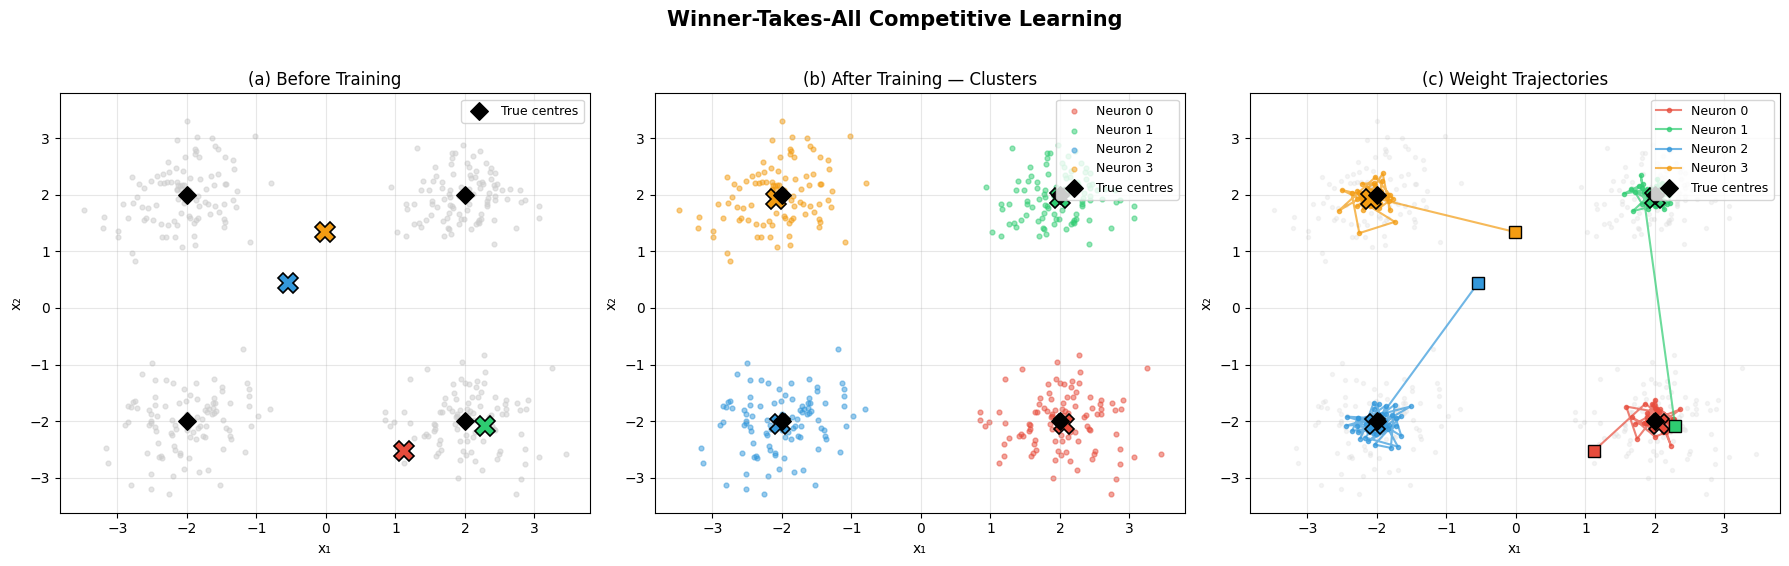

In [6]:
palette = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle("Winner-Takes-All Competitive Learning",
             fontsize=15, fontweight="bold", y=1.02)

# ---- (a) Before training ----
ax = axes[0]
ax.scatter(data[:, 0], data[:, 1], c="#cccccc", s=12, alpha=0.5)
init_w = weight_history[0]
for k in range(N_NEURONS):
    ax.plot(init_w[k, 0], init_w[k, 1], marker="X", markersize=14,
            color=palette[k], markeredgecolor="black", markeredgewidth=1.2)
ax.scatter(cluster_centres[:, 0], cluster_centres[:, 1],
           marker="D", s=80, c="black", zorder=5, label="True centres")
ax.set_title("(a) Before Training", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.grid(True, alpha=0.3)

# ---- (b) After training with cluster assignments ----
ax = axes[1]
for k in range(N_NEURONS):
    mask = assignments == k
    ax.scatter(data[mask, 0], data[mask, 1], c=palette[k], s=12, alpha=0.5,
               label=f"Neuron {k}")
    ax.plot(weights[k, 0], weights[k, 1], marker="X", markersize=14,
            color=palette[k], markeredgecolor="black", markeredgewidth=1.2)
ax.scatter(cluster_centres[:, 0], cluster_centres[:, 1],
           marker="D", s=80, c="black", zorder=5, label="True centres")
ax.set_title("(b) After Training — Clusters", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.grid(True, alpha=0.3)

# ---- (c) Weight trajectories ----
ax = axes[2]
ax.scatter(data[:, 0], data[:, 1], c="#dddddd", s=8, alpha=0.3)
for k in range(N_NEURONS):
    traj = np.array([wh[k] for wh in weight_history])
    ax.plot(traj[:, 0], traj[:, 1], "-o", markersize=3, color=palette[k],
            alpha=0.7, linewidth=1.5, label=f"Neuron {k}")
    # Start marker
    ax.plot(traj[0, 0], traj[0, 1], "s", markersize=8, color=palette[k],
            markeredgecolor="black")
    # End marker
    ax.plot(traj[-1, 0], traj[-1, 1], "X", markersize=14, color=palette[k],
            markeredgecolor="black", markeredgewidth=1.2)
ax.scatter(cluster_centres[:, 0], cluster_centres[:, 1],
           marker="D", s=80, c="black", zorder=5, label="True centres")
ax.set_title("(c) Weight Trajectories", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlabel("x₁")
ax.set_ylabel("x₂")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Summary Table

In [7]:
print("\n" + "=" * 60)
print("  Winner-Takes-All — Learned vs True Cluster Centres")
print("=" * 60)
print(f"  {'Neuron':<8} {'Learned Centre':<22} {'Nearest True Centre':<22} {'Dist':>6}")
print("-" * 60)

for k in range(N_NEURONS):
    # Find the closest true centre for this neuron
    dists_to_true = np.linalg.norm(cluster_centres - weights[k], axis=1)
    closest = np.argmin(dists_to_true)
    tc = cluster_centres[closest]
    d = dists_to_true[closest]
    print(f"  {k:^8} ({weights[k,0]:>+6.3f}, {weights[k,1]:>+6.3f})    "
          f"({tc[0]:>+6.3f}, {tc[1]:>+6.3f})    {d:>6.3f}")

print("=" * 60)


  Winner-Takes-All — Learned vs True Cluster Centres
  Neuron   Learned Centre         Nearest True Centre      Dist
------------------------------------------------------------
     0     (+2.058, -2.046)    (+2.000, -2.000)     0.074
     1     (+1.996, +1.951)    (+2.000, +2.000)     0.049
     2     (-2.024, -2.050)    (-2.000, -2.000)     0.055
     3     (-2.086, +1.930)    (-2.000, +2.000)     0.111
